# Lab01 - PlayersExt.csv

**Group members:**

|Student Name|Student ID|
|--|--|
|Le Tuan Anh|20214874|
|Vu Tuan Minh|20210597|
|Bui Minh Quang|20214925|
|Dinh Nguyen Cong Quy (C)|20214927|
|Phan Dinh Truong|20214937|

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df1 = pd.read_csv(r'C:\python code\Intro to Data Science\Untitled Folder\Players.csv')
df2 = pd.read_csv(r'C:\python code\Intro to Data Science\Untitled Folder\Teams.csv')

In [3]:
df1.head()

,surname,team,position,minutes,shots,passes,tackles,saves
0,Abdoun,Algeria,midfielder,16,0,6,0,0
1,Belhadj,Algeria,defender,270,1,146,8,0
2,Boudebouz,Algeria,midfielder,74,3,28,1,0
3,Bougherra,Algeria,defender,270,1,89,11,0
4,Chaouchi,Algeria,goalkeeper,90,0,17,0,2


In [4]:
df2.head()

,team,ranking,games,wins,draws,losses,goalsFor,goalsAgainst,yellowCards,redCards
0,Brazil,1,5,3,1,1,9,4,7,2
1,Spain,2,6,5,0,1,7,2,3,0
2,Portugal,3,4,1,2,1,7,1,8,1
3,Netherlands,4,6,6,0,0,12,5,15,0
4,Italy,5,3,0,2,1,4,5,5,0


# Create a bar chart showing the average number of minutes played by players in each of the four positions.

Text(0, 0.5, 'Percentage Ranges')

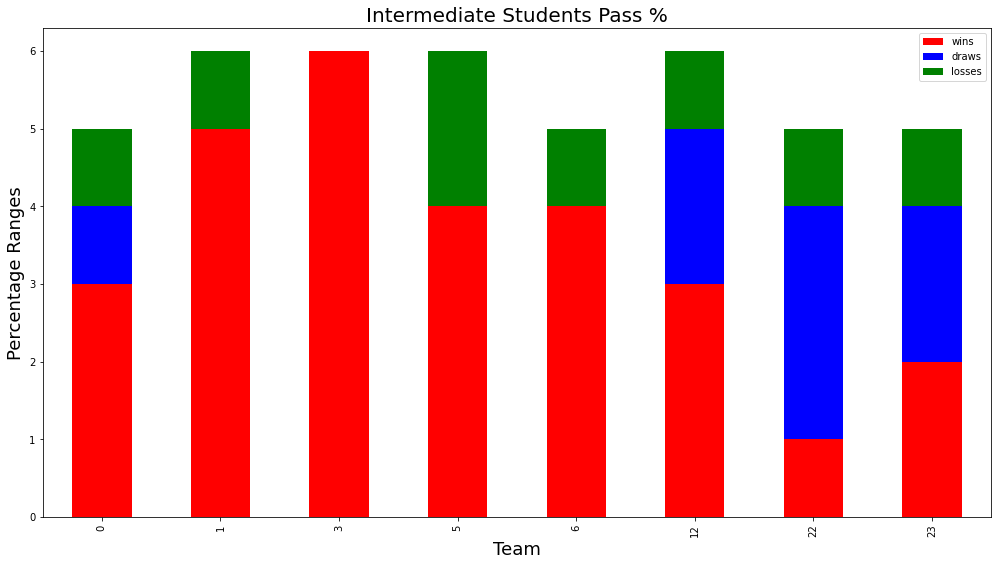

In [5]:
ex2_df = df2.loc[df2['games'] > 4]
ex2_df = ex2_df[["team", "wins", "draws", "losses"]]


ex2_df.plot(kind='bar', stacked=True, color=['red', 'blue', 'green'], figsize = (17,9))

# Add Title and Labels

plt.title('Intermediate Students Pass %', fontsize = 20)
plt.xlabel('Team', fontsize = 18)
plt.ylabel('Percentage Ranges', fontsize = 18)

# Create a stacked bar chart for teams that played more than 4 games, showing their number of wins, draws, and losses

In [6]:
red_cards_count = df2['redCards'].value_counts()
red_cards_count

0    20
1     8
2     4
Name: redCards, dtype: int64

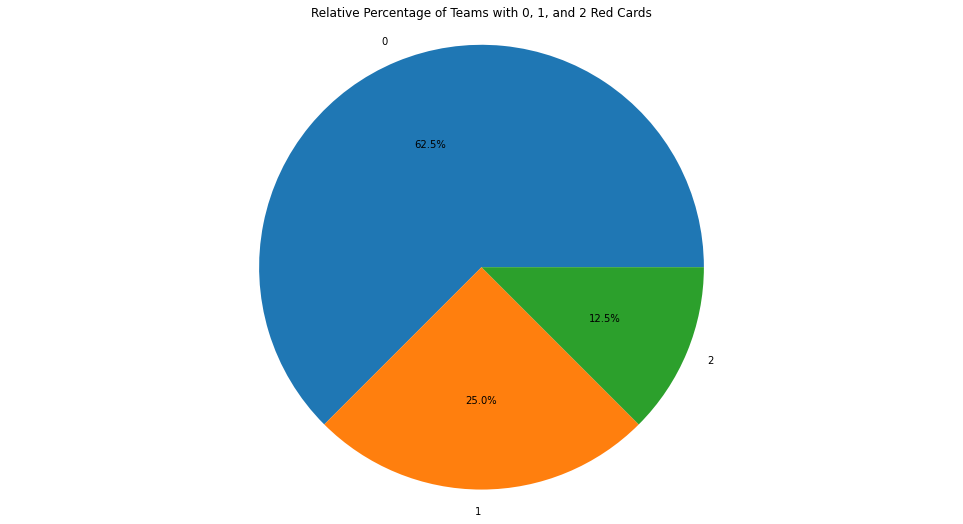

In [7]:
relative_percentages = red_cards_count / red_cards_count.sum()

plt.figure(figsize = (17,9))
plt.pie(relative_percentages.values, labels=relative_percentages.index, autopct='%1.1f%%')

plt.title('Relative Percentage of Teams with 0, 1, and 2 Red Cards')
plt.axis('equal') 

plt.show()

# Create a pie chart showing the relative percentage of teams with 0, 1, and 2 red cards. Note: the pie should have three slices.

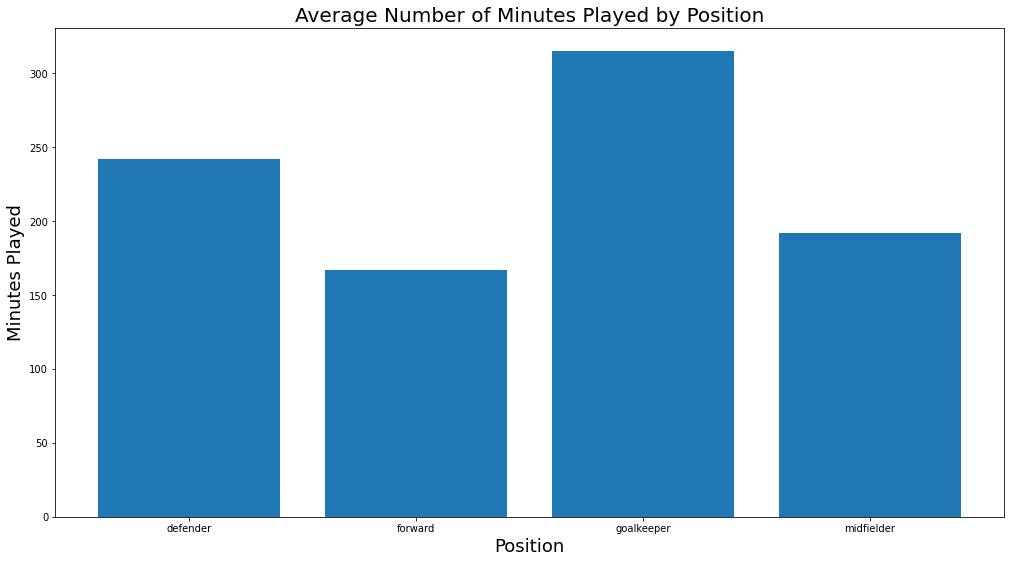

In [8]:
ex1_df_grp = df1.groupby('position')
ex1_df_grp = ex1_df_grp['minutes'].mean()

plt.figure(figsize = (17,9))
plt.bar(ex1_df_grp.index, ex1_df_grp.values)

plt.title('Average Number of Minutes Played by Position', fontsize = 20)
plt.xlabel('Position', fontsize = 18)
plt.ylabel('Minutes Played', fontsize = 18)

plt.show()

# Create a scatterplot of players showing passes (y-axis) versus minutes (x-axis). (Why are there some lines of dots?)

--> Answer: The lines of dots suggest that there is a strong relationship between the two variables, i.e, players who play more minutes tend to make more passes.

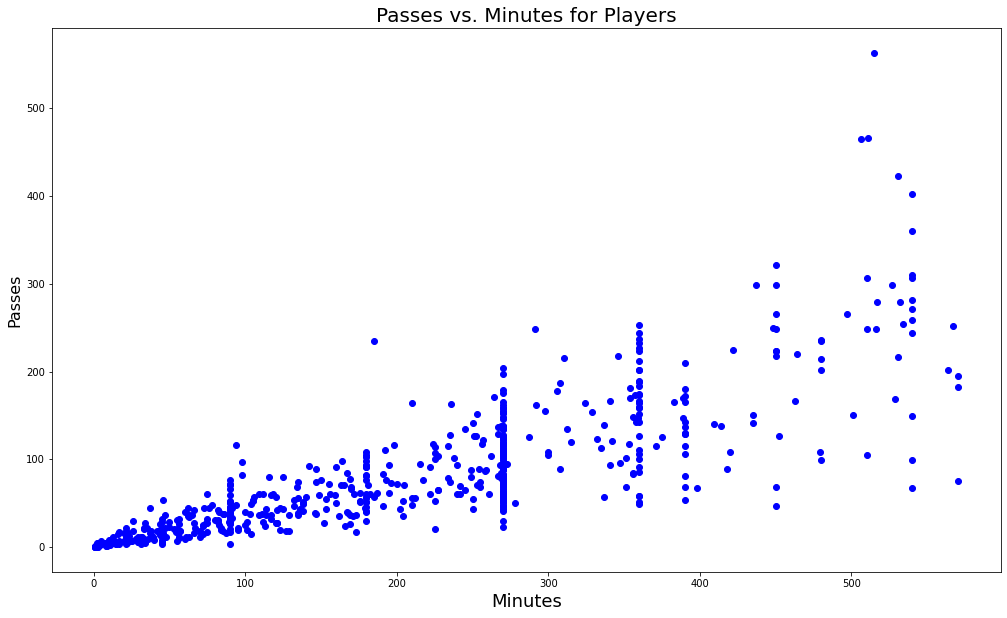

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(17, 10))
plt.scatter(df1['minutes'], df1['passes'], c='b', marker='o', label='Passes')


plt.xlabel('Minutes', fontsize = 18)
plt.ylabel('Passes', fontsize = 16)
plt.title('Passes vs. Minutes for Players', fontsize = 20)

plt.show()


#  Create a map of countries colored light to dark blue based on how many goals their team made (“goalsFor”)

C:\Users\DELL\AppData\Local\Temp/ipykernel_6956/4152163744.py:4: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


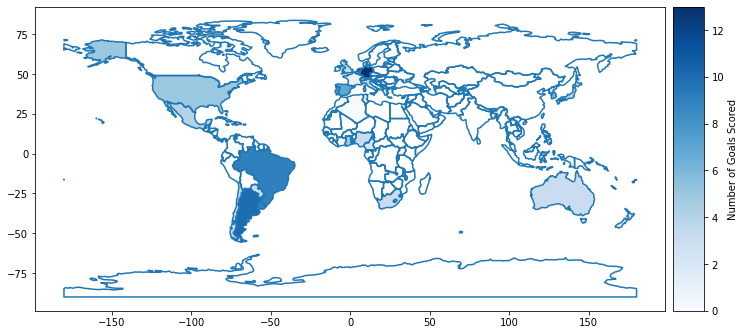

In [10]:
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable
team = df2
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
name_mapping = {
    "USA":"United States of America",
    "England":"United Kingdom"
}
team['mapped_name'] = team['team'].map(name_mapping)
team['mapped_name'].fillna(team['team'], inplace=True)

world = world.merge(team, how='left', left_on='name', right_on='mapped_name')

cmap = plt.get_cmap('Blues')

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

world.boundary.plot(ax=ax)
world.plot(column='goalsFor', ax=ax, legend=True, cax=cax,
           cmap=cmap, legend_kwds={'label': "Number of Goals Scored"})

plt.show()

# Create a pie chart showing the relative percentage of players making <= 0.25 passes per minute, >= 0.5 passes per minute, and between 0.25 and 0.5

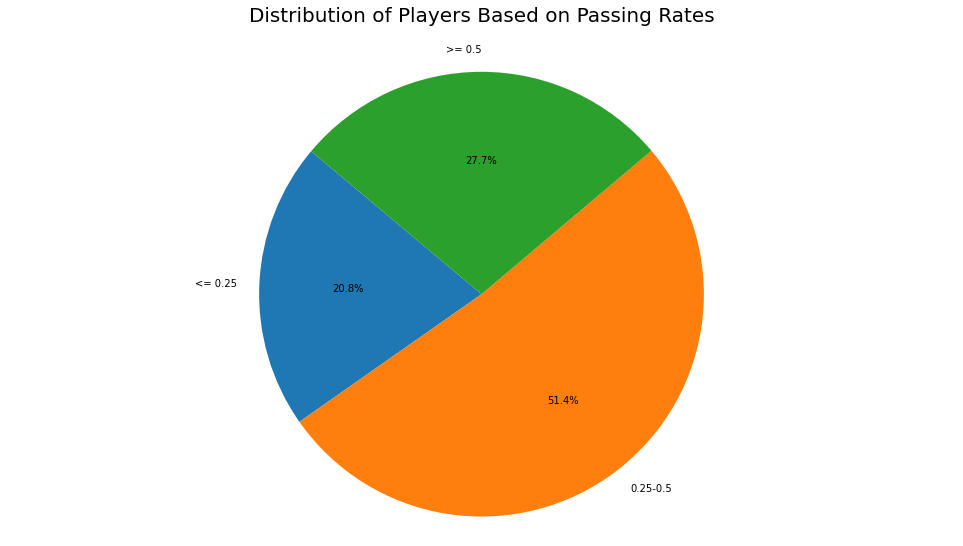

In [11]:
df1['Passes per Minute'] = df1['passes'] / df1['minutes']

passes_low = df1[df1['Passes per Minute'] <= 0.25]
passes_medium = df1[(df1['Passes per Minute'] > 0.25) & (df1['Passes per Minute'] < 0.5)]
passes_high = df1[df1['Passes per Minute'] >= 0.5]

low_count = len(passes_low)
medium_count = len(passes_medium)
high_count = len(passes_high)

labels = ['<= 0.25', '0.25-0.5', '>= 0.5']
sizes = [low_count, medium_count, high_count]
plt.figure(figsize = (17,9))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.axis('equal') 
plt.title('Distribution of Players Based on Passing Rates' + "\n", fontsize = 20)
plt.show()